# Bayesian Decision and Uncertainty: Skin Lesion Triage

Melanoma-vs-benign triage on the HAM10000 dataset. The workflow excludes `bcc` and `akiec`
(malignant / pre-malignant categories that are neither melanoma nor benign and would blur a clean
melanoma-vs-benign task), uses lesion-aware **and** class-stratified splitting, fits an
HSV-histogram + GMM Bayesian classical baseline, compares it against a fine-tuned EfficientNet-B0
with MC-Dropout uncertainty, and evaluates both under **asymmetric-cost Bayesian decision rules**
on the same held-out internal test split.

Key design choices:
- **Natural class prevalence is kept** (melanoma is a small minority of lesions). The point of the
  Bayesian decision-theory framing is that the *true* prior and an *asymmetric cost* — not
  artificial class balancing — drive the decision threshold.
- **The classical GMM pipeline is taken all the way to a decision**: MAP threshold, asymmetric-cost
  threshold, confusion matrices, and a reliability diagram, exactly as for the deep model.
- **A single cost-sweep table and a per-lesion prediction file** let classical-vs-deep decisions be
  compared directly on the same test lesions.
- **`FINE_TUNE_BACKBONE` toggle** selects between a frozen EfficientNet-B0 (only the classification
  head trained) and a two-stage recipe that additionally fine-tunes the last blocks at a low
  learning rate; the latter is the default and usually improves AUC.

## Setup and Reproducible Configuration

In [22]:
import os
import random
import warnings
import json
import platform
from copy import deepcopy
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
from PIL import Image
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    auc, brier_score_loss, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

warnings.filterwarnings("ignore")

import time
NOTEBOOK_START_TIME = time.time()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

GPU_COUNT = torch.cuda.device_count()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### Configuration

Hyperparameters, the GMM search range, and the asymmetric cost matrix — logged to `run_config.json` at the end of the run.

In [23]:
# Kaggle T4 x2 often bottlenecks on CPU image loading. A larger batch helps amortize
# transfer/launch overhead. DataParallel is disabled by default because it is usually
# less efficient than one-GPU training in notebooks unless the input pipeline is fast.
USE_DATA_PARALLEL = False
BATCH_SIZE = 128 if torch.cuda.is_available() else 32
NUM_WORKERS = min(8, os.cpu_count() or 8)
PREFETCH_FACTOR = 4 if NUM_WORKERS > 0 else None

# Staged training: fit the head first, then optionally fine-tune the last EfficientNet blocks.
# FINE_TUNE_BACKBONE=False keeps the backbone frozen (only the classification head trains);
# True (default) additionally fine-tunes the last blocks at a low LR, which usually improves AUC.
FINE_TUNE_BACKBONE = True
HEAD_EPOCHS = 6
FINE_TUNE_EPOCHS = 6
UNFREEZE_LAST_BLOCKS = 2
HEAD_LR = 1e-3
FINE_TUNE_LR = 1e-5
WEIGHT_DECAY = 1e-4
MC_PASSES = 30

# Feature and cost configuration, recorded explicitly for reproducibility
# (feature type, GMM component search range, and cost matrix).
HSV_BINS = 32
GMM_MAX_COMPONENTS = 30          # search range for BIC-based component selection
GMM_FIT_SUBSAMPLE = 2000         # class-stratified subsample of the fit split

# Primary asymmetric cost matrix used for the headline decision throughout the notebook.
# A missed melanoma (false negative) is treated as far more costly than an unnecessary
# referral (false positive) — this drives the asymmetric decision threshold below.
FN_COST = 10
FP_COST = 1
COST_SWEEP = [(1, 1), (5, 1), (10, 1), (20, 1)]  # (l_fn, l_fp) ratios for the fuller sweep

print(f"Using device: {device}")
print(f"CUDA devices: {GPU_COUNT}")
for i in range(GPU_COUNT):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
print(f"Batch size: {BATCH_SIZE}; workers: {NUM_WORKERS}; prefetch: {PREFETCH_FACTOR}")
print(f"Head epochs: {HEAD_EPOCHS}; fine-tune epochs: {FINE_TUNE_EPOCHS} (enabled={FINE_TUNE_BACKBONE}); last blocks: {UNFREEZE_LAST_BLOCKS}")
print(f"Primary cost matrix -> FN_COST:{FN_COST}, FP_COST:{FP_COST}")
print(f"Outputs directory: {OUTPUT_DIR.resolve()}")

# Record package versions for reproducibility.
print("\nPackage versions:")
print(f"  python={platform.python_version()}, torch={torch.__version__}, "
      f"sklearn={sklearn.__version__}, opencv={cv2.__version__}, "
      f"pandas={pd.__version__}, numpy={np.__version__}")

Using device: cuda
CUDA devices: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Batch size: 128; workers: 4; prefetch: 4
Head epochs: 6; fine-tune epochs: 6 (enabled=True); last blocks: 2
Primary cost matrix -> FN_COST:10, FP_COST:1
Outputs directory: /kaggle/working/outputs

Package versions:
  python=3.12.12, torch=2.10.0+cu128, sklearn=1.6.1, opencv=4.13.0, pandas=2.3.3, numpy=2.0.2


## Load and Filter HAM10000

The notebook expects the Kaggle HAM10000 mirror (`kmader/skin-cancer-mnist-ham10000`):
`HAM10000_metadata.csv` plus `HAM10000_images_part_1/2`. It builds all fit/val/cal/test splits
from that training pool with lesion-aware grouping so images of the same lesion never cross splits.

Class counts are naturally imbalanced (melanoma is a small minority); we keep that prevalence
rather than balancing it, and report it explicitly below.

In [ ]:
import glob

def find_file(filename, search_root="/kaggle/input"):
    matches = glob.glob(os.path.join(search_root, "**", filename), recursive=True)
    return matches[0] if matches else None

def find_dir(dirname, search_root="/kaggle/input"):
    matches = [m for m in glob.glob(os.path.join(search_root, "**", dirname), recursive=True) if os.path.isdir(m)]
    return matches[0] if matches else None

# Robust path discovery: works regardless of the exact Kaggle dataset slug as long as the
# HAM10000 metadata and image folder names are present.
TRAIN_METADATA_CSV = find_file("HAM10000_metadata.csv")
TRAIN_IMG_DIRS = [d for d in [find_dir("HAM10000_images_part_1"), find_dir("HAM10000_images_part_2")] if d]
if TRAIN_METADATA_CSV is None or not TRAIN_IMG_DIRS:
    raise FileNotFoundError(
        "Could not find HAM10000_metadata.csv / HAM10000_images_part_1/2 under /kaggle/input. "
        "Attach the HAM10000 dataset (kmader/skin-cancer-mnist-ham10000)."
    )

def load_metadata(csv_path, img_dirs):
    frame = pd.read_csv(csv_path)
    frame = frame[~frame["dx"].isin(["bcc", "akiec"])].reset_index(drop=True)
    frame["target"] = (frame["dx"] == "mel").astype(int)

    def resolve(image_id):
        for img_dir in img_dirs:
            path = os.path.join(img_dir, f"{image_id}.jpg")
            if os.path.exists(path):
                return path
        raise FileNotFoundError(f"Image not found: {image_id}")

    frame["image_path"] = frame["image_id"].map(resolve)
    return frame

trainpool_df = load_metadata(TRAIN_METADATA_CSV, TRAIN_IMG_DIRS)
print("Training pool (HAM10000_metadata.csv):")
print(trainpool_df["dx"].value_counts())
print(f"  rows={len(trainpool_df):,}, melanoma prevalence={trainpool_df['target'].mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
trainpool_df["dx"].value_counts().plot(
    kind="bar", ax=ax,
    color=["#d62728" if c == "mel" else "#1f77b4" for c in trainpool_df["dx"].value_counts().index],
)
ax.set_ylabel("count")
ax.set_title("Training-pool class balance after excluding bcc/akiec (mel = melanoma, red)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_balance.png", dpi=160)
plt.show()

## Reproducible, Leakage-Free, Stratified Split

The HAM10000 training pool is split into four disjoint, lesion-grouped, class-stratified sets with
`StratifiedGroupKFold` (stratifies on `target` while keeping every image of a given lesion in the
same split, so no lesion's images end up split across two sets):

- **`fit`** — trains the GMMs and the EfficientNet head/backbone.
- **`val`** — used only to pick the best training checkpoint (early-stopping proxy). Never used for
  calibration or final metrics.
- **`cal`** — used only to fit Platt scaling and to pick sensitivity-based operating thresholds.
- **`test`** — touched only in the final evaluation/comparison cells.

In [ ]:
# Carve a stratified, lesion-grouped test split out of the HAM10000 training pool.
sgkf_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
remaining_idx, test_idx = next(sgkf_test.split(trainpool_df, trainpool_df["target"], groups=trainpool_df["lesion_id"]))
remaining_pool_df = trainpool_df.iloc[remaining_idx].reset_index(drop=True)
test_df = trainpool_df.iloc[test_idx].reset_index(drop=True)

sgkf_cal = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
fitval_idx, cal_idx = next(sgkf_cal.split(remaining_pool_df, remaining_pool_df["target"], groups=remaining_pool_df["lesion_id"]))
fitval_df = remaining_pool_df.iloc[fitval_idx].reset_index(drop=True)
cal_df = remaining_pool_df.iloc[cal_idx].reset_index(drop=True)

sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
fit_idx, val_idx = next(sgkf_val.split(fitval_df, fitval_df["target"], groups=fitval_df["lesion_id"]))
fit_df = fitval_df.iloc[fit_idx].reset_index(drop=True)
val_df = fitval_df.iloc[val_idx].reset_index(drop=True)

# Leakage check across ALL pairs of splits (lesion_id must never appear in two splits).
_groups = {
    "fit": set(fit_df["lesion_id"]), "val": set(val_df["lesion_id"]),
    "cal": set(cal_df["lesion_id"]), "test": set(test_df["lesion_id"]),
}
_names = list(_groups)
for i in range(len(_names)):
    for j in range(i + 1, len(_names)):
        assert _groups[_names[i]].isdisjoint(_groups[_names[j]]), f"Leakage between {_names[i]} and {_names[j]}"

print("Split sizes and class prevalence (should be similar across splits if stratification worked):")
for name, d in [("fit", fit_df), ("val", val_df), ("cal", cal_df), ("test", test_df)]:
    print(f"  {name:5s}: rows={len(d):5d}, lesions={d['lesion_id'].nunique():5d}, prevalence={d['target'].mean():.3f}")

# Persist the exact split assignment for reproducibility.
split_records = []
for name, d in [("fit", fit_df), ("val", val_df), ("cal", cal_df), ("test", test_df)]:
    tmp = d[["image_id", "lesion_id", "dx", "target"]].copy()
    tmp["split"] = name
    split_records.append(tmp)
pd.concat(split_records, ignore_index=True).to_csv(OUTPUT_DIR / "split_assignment.csv", index=False)
print(f"Saved {OUTPUT_DIR / 'split_assignment.csv'}")

## Classical Baseline: HSV Histograms + GMM

**Theory — Bayes decision rule.** For class-conditional densities $p(x \mid \text{mel})$, $p(x \mid \text{benign})$
estimated by the GMMs below and priors $\pi_{\text{mel}}, \pi_{\text{benign}}$ estimated from the training
prevalence, Bayes' rule gives the posterior

$$P(\text{mel} \mid x) = \frac{p(x\mid\text{mel})\,\pi_{\text{mel}}}{p(x\mid\text{mel})\,\pi_{\text{mel}} + p(x\mid\text{benign})\,\pi_{\text{benign}}}.$$

Under 0/1 loss, the optimal decision is MAP: predict melanoma when $P(\text{mel}\mid x) \ge 0.5$. Under an
asymmetric cost matrix with $L_{FN}$ (cost of missing a melanoma) and $L_{FP}$ (cost of an unnecessary
referral), the expected-cost-minimizing threshold shifts to

$$\tau^\* = \frac{L_{FP}}{L_{FP} + L_{FN}}.$$

With $L_{FN}=10, L_{FP}=1$ this gives $\tau^\* \approx 0.091$ — the classifier should flag anything above a
~9% estimated melanoma probability, trading specificity for a much lower false-negative rate. This is the
concrete decision the notebook reports.

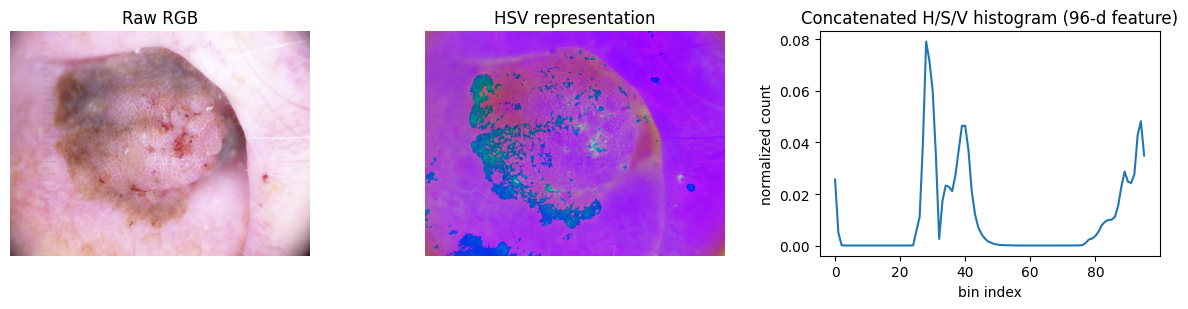

In [26]:
def extract_hsv_hist(path, bins=HSV_BINS):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist_h = cv2.calcHist([hsv], [0], None, [bins], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [bins], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [bins], [0, 256]).flatten()
    features = np.concatenate([hist_h, hist_s, hist_v]).astype(np.float32)
    return features / (features.sum() + 1e-7)

# Visualize the raw image, its HSV representation, and the resulting histogram feature.
_sample_path = fit_df["image_path"].iloc[0]
_sample_bgr = cv2.imread(_sample_path)
_sample_rgb = cv2.cvtColor(_sample_bgr, cv2.COLOR_BGR2RGB)
_sample_hsv = cv2.cvtColor(_sample_bgr, cv2.COLOR_BGR2HSV)
_sample_feat = extract_hsv_hist(_sample_path)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].imshow(_sample_rgb); axes[0].set_title("Raw RGB"); axes[0].axis("off")
axes[1].imshow(_sample_hsv); axes[1].set_title("HSV representation"); axes[1].axis("off")
axes[2].plot(_sample_feat)
axes[2].set_title(f"Concatenated H/S/V histogram ({3*HSV_BINS}-d feature)")
axes[2].set_xlabel("bin index"); axes[2].set_ylabel("normalized count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "raw_vs_processed_feature.png", dpi=160)
plt.show()

In [27]:
# Class-stratified subsample of the fit split for GMM fitting (keeps the minority melanoma
# proportion controlled). All evaluation below uses the full test split.
_gmm_fit_n = min(GMM_FIT_SUBSAMPLE, len(fit_df))
fit_sub_df, _ = train_test_split(
    fit_df, train_size=_gmm_fit_n, stratify=fit_df["target"], random_state=SEED
)

X_fit_gmm = np.stack([extract_hsv_hist(p) for p in fit_sub_df["image_path"]])
y_fit_gmm = fit_sub_df["target"].to_numpy()

X_val_gmm = np.stack([extract_hsv_hist(p) for p in val_df["image_path"]])
y_val_gmm = val_df["target"].to_numpy()

X_test_gmm = np.stack([extract_hsv_hist(p) for p in test_df["image_path"]])
y_test_gmm = test_df["target"].to_numpy()

bic_scores = []
class_max_k = []  # guard: never request more components than a class has samples
for cls in range(2):
    bic = []
    Xc = X_fit_gmm[y_fit_gmm == cls]
    max_k = min(GMM_MAX_COMPONENTS, len(Xc))
    class_max_k.append(max_k)
    for n in range(1, max_k + 1):
        gm = GaussianMixture(n_components=n, covariance_type="diag", random_state=SEED)
        gm.fit(Xc)
        bic.append(gm.bic(Xc))
    bic_scores.append(bic)
if class_max_k[0] < GMM_MAX_COMPONENTS or class_max_k[1] < GMM_MAX_COMPONENTS:
    print(f"NOTE: BIC search range capped by sample size -- benign max_k={class_max_k[0]}, "
          f"melanoma max_k={class_max_k[1]} (requested {GMM_MAX_COMPONENTS}).")

k_benign = int(np.argmin(bic_scores[0])) + 1
k_mel = int(np.argmin(bic_scores[1])) + 1
# Report the selected K explicitly and warn if BIC picked a value at the search boundary,
# which can indicate the search range is too small or the fit is unstable for the smaller
# melanoma class.
print(f"Selected GMM components via BIC: benign K={k_benign}, melanoma K={k_mel} "
      f"(search range 1-{GMM_MAX_COMPONENTS}, fit melanoma n={int((y_fit_gmm==1).sum())})")
for name, k in [("benign", k_benign), ("melanoma", k_mel)]:
    if k >= GMM_MAX_COMPONENTS - 2:
        print(f"  WARNING: {name} K={k} is near the search boundary — inspect the BIC curve "
              f"below before trusting this; consider widening the search or checking for overfitting.")

gmm_benign = GaussianMixture(n_components=k_benign, covariance_type="diag", random_state=SEED)
gmm_mel = GaussianMixture(n_components=k_mel, covariance_type="diag", random_state=SEED)
gmm_benign.fit(X_fit_gmm[y_fit_gmm == 0])
gmm_mel.fit(X_fit_gmm[y_fit_gmm == 1])

prior_mel = y_fit_gmm.mean()

def gmm_posterior(X):
    log_benign = gmm_benign.score_samples(X) + np.log(1 - prior_mel + 1e-10)
    log_mel = gmm_mel.score_samples(X) + np.log(prior_mel + 1e-10)
    return 1 / (1 + np.exp(log_benign - log_mel))

# Quick sanity check on val (never used for final reporting) before committing to test metrics.
gmm_probs_val = gmm_posterior(X_val_gmm)
val_fpr, val_tpr, _ = roc_curve(y_val_gmm, gmm_probs_val)
print(f"GMM val-set AUC (sanity check, not reported as final): {auc(val_fpr, val_tpr):.3f}")

# Final, reportable classical metrics: FULL test split (was a random 500-row subsample before).
gmm_probs_test = gmm_posterior(X_test_gmm)
gmm_fpr, gmm_tpr, _ = roc_curve(y_test_gmm, gmm_probs_test)
print(f"GMM TEST-set AUC (final, reported): {auc(gmm_fpr, gmm_tpr):.3f}")

Selected GMM components via BIC: benign K=28, melanoma K=8 (search range 1-30, fit melanoma n=264)
GMM val-set AUC (sanity check, not reported as final): 0.808
GMM TEST-set AUC (final, reported): 0.805


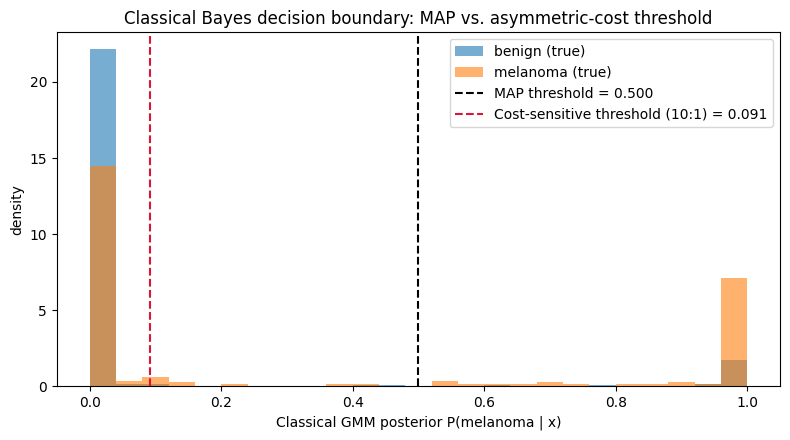

In [28]:
# Visualize the Bayes decision boundary: per-class posterior histograms with the MAP and
# asymmetric-cost thresholds overlaid.
tau_map = 0.5
tau_cost = FP_COST / (FP_COST + FN_COST)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(gmm_probs_test[y_test_gmm == 0], bins=25, alpha=0.6, density=True, label="benign (true)")
ax.hist(gmm_probs_test[y_test_gmm == 1], bins=25, alpha=0.6, density=True, label="melanoma (true)")
ax.axvline(tau_map, color="black", linestyle="--", label=f"MAP threshold = {tau_map:.3f}")
ax.axvline(tau_cost, color="crimson", linestyle="--",
           label=f"Cost-sensitive threshold ({FN_COST}:{FP_COST}) = {tau_cost:.3f}")
ax.set_xlabel("Classical GMM posterior P(melanoma | x)")
ax.set_ylabel("density")
ax.set_title("Classical Bayes decision boundary: MAP vs. asymmetric-cost threshold")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bayes_decision_boundary.png", dpi=160)
plt.show()

### Classical decision rule: MAP vs. asymmetric cost (test set)

The same decision-theoretic machinery used for the deep model is applied to the classical GMM:
derive the decision threshold from the asymmetric cost matrix, compare it against the MAP (0.5)
threshold, and evaluate the resulting decisions with a confusion matrix and reliability diagram
(further down). The cell below builds the classical cost-sweep table on the held-out test set.

In [29]:
def metrics_at_threshold(probs, y_true, tau):
    preds = (probs >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    return {
        "sensitivity": sensitivity, "specificity": specificity, "precision": precision,
        "referral_rate": preds.mean(), "false_negatives": int(fn), "false_positives": int(fp),
        "true_negatives": int(tn), "true_positives": int(tp),
    }

def evaluate_threshold(probs, y_true, l_fn, l_fp, model_name):
    tau = l_fp / (l_fp + l_fn)
    row = {"model": model_name, "cost_ratio_fn_fp": f"{l_fn}:{l_fp}", "threshold": tau}
    row.update(metrics_at_threshold(probs, y_true, tau))
    return row

# Cost-sweep table for the classical model on the test split. Deep-model rows are appended to
# this table once the deep predictions are computed in the calibration section below.
classical_cost_rows = [
    evaluate_threshold(gmm_probs_test, y_test_gmm, l_fn, l_fp, "classical_gmm")
    for l_fn, l_fp in COST_SWEEP
]
classical_cost_df = pd.DataFrame(classical_cost_rows)
print("Classical GMM: MAP (1:1) vs. asymmetric-cost thresholds on the held-out test set")
print(classical_cost_df.to_string(index=False, formatters={
    "threshold": "{:.3f}".format, "sensitivity": "{:.3f}".format,
    "specificity": "{:.3f}".format, "precision": "{:.3f}".format, "referral_rate": "{:.3f}".format,
}))

Classical GMM: MAP (1:1) vs. asymmetric-cost thresholds on the held-out test set
        model cost_ratio_fn_fp threshold sensitivity specificity precision referral_rate  false_negatives  false_positives  true_negatives  true_positives
classical_gmm              1:1     0.500       0.355       0.908     0.317         0.120              129              153            1507              71
classical_gmm              5:1     0.167       0.370       0.898     0.305         0.131              126              169            1491              74
classical_gmm             10:1     0.091       0.385       0.892     0.301         0.138              123              179            1481              77
classical_gmm             20:1     0.048       0.420       0.886     0.308         0.147              116              189            1471              84


## EfficientNet-B0 with MC Dropout

**`FINE_TUNE_BACKBONE`:** with `False`, the EfficientNet-B0 backbone stays frozen and only the
classification head is trained. With `True` (default) the notebook additionally unfreezes the last
two blocks and fine-tunes them at a low learning rate, which typically improves AUC. Set the flag
in the configuration cell and re-run to switch between the two.

### Dataset, transforms, and data loaders

In [30]:
class HAMDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row["target"], dtype=torch.float32)
        if self.transform is not None:
            image = self.transform(image)
        return image, label

weights = EfficientNet_B0_Weights.IMAGENET1K_V1
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Keep augmentation useful but moderate. RandomRotation and ColorJitter are CPU-heavy.
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
}
if NUM_WORKERS > 0:
    loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

# One loader per split: fit uses training augmentation, the others are eval-only.
fit_loader = DataLoader(HAMDataset(fit_df, transform_train), batch_size=BATCH_SIZE, shuffle=True, **loader_kwargs)
val_loader = DataLoader(HAMDataset(val_df, transform_eval), batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
cal_loader = DataLoader(HAMDataset(cal_df, transform_eval), batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(HAMDataset(test_df, transform_eval), batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

### Training helper functions

In [31]:
def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model

def set_backbone_trainable(model, trainable=False, last_blocks=0):
    base = unwrap_model(model)
    for param in base.features.parameters():
        param.requires_grad = False
    if trainable and last_blocks > 0:
        blocks = list(base.features.children())
        for block in blocks[-last_blocks:]:
            for param in block.parameters():
                param.requires_grad = True
    for param in base.classifier.parameters():
        param.requires_grad = True

def make_optimizer(model, lr):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)

def predict_probs(model, loader):
    model.eval()
    probs = []
    targets = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits = model(images).squeeze(1)
            probs.append(torch.sigmoid(logits).float().cpu().numpy())
            targets.extend(labels.numpy())
    return np.concatenate(probs), np.asarray(targets)

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)

### Model and two-stage training loop

Build EfficientNet-B0 with an MC-Dropout head, train the head, then optionally fine-tune the last blocks. The best checkpoint is chosen on the val split.

In [32]:
model = models.efficientnet_b0(weights=weights)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=False),
    nn.Linear(1280, 1),
)
model = model.to(device)

if USE_DATA_PARALLEL and GPU_COUNT >= 2:
    model = nn.DataParallel(model)
    print(f"DataParallel enabled across {GPU_COUNT} GPUs")
elif GPU_COUNT >= 2:
    print("Multiple GPUs detected, but DataParallel is disabled. Using one GPU to avoid notebook input-pipeline overhead.")

# Use unweighted BCE so logits can be calibrated as posterior melanoma probabilities.
# Class imbalance is handled at decision time with asymmetric thresholds, not baked into training.
criterion = nn.BCEWithLogitsLoss()
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
history = []
best_auc = -np.inf
best_state = None

set_backbone_trainable(model, trainable=False)
optimizer = make_optimizer(model, HEAD_LR)
print(f"Head training: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable params")
_head_start = time.time()
for epoch in range(1, HEAD_EPOCHS + 1):
    loss = train_one_epoch(model, fit_loader, criterion, optimizer, scaler)
    # Checkpoint selection uses the val split, never the held-out test set.
    val_probs_epoch, val_targets_epoch = predict_probs(model, val_loader)
    val_auc_epoch = roc_auc_score(val_targets_epoch, val_probs_epoch)
    history.append({"stage": "head", "epoch": epoch, "loss": loss, "val_auc": val_auc_epoch})
    print(f"head {epoch:02d}/{HEAD_EPOCHS} - loss: {loss:.4f} - val_auc: {val_auc_epoch:.4f}")
    if val_auc_epoch > best_auc:
        best_auc = val_auc_epoch
        best_state = deepcopy(unwrap_model(model).state_dict())
head_train_seconds = time.time() - _head_start

# Optional fine-tuning stage, gated by FINE_TUNE_BACKBONE (skipped for a frozen-backbone run).
fine_tune_seconds = 0.0
if FINE_TUNE_BACKBONE:
    set_backbone_trainable(model, trainable=True, last_blocks=UNFREEZE_LAST_BLOCKS)
    optimizer = make_optimizer(model, FINE_TUNE_LR)
    print(f"Fine-tuning: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable params")
    _ft_start = time.time()
    for epoch in range(1, FINE_TUNE_EPOCHS + 1):
        loss = train_one_epoch(model, fit_loader, criterion, optimizer, scaler)
        val_probs_epoch, val_targets_epoch = predict_probs(model, val_loader)
        val_auc_epoch = roc_auc_score(val_targets_epoch, val_probs_epoch)
        history.append({"stage": "fine_tune", "epoch": epoch, "loss": loss, "val_auc": val_auc_epoch})
        print(f"fine_tune {epoch:02d}/{FINE_TUNE_EPOCHS} - loss: {loss:.4f} - val_auc: {val_auc_epoch:.4f}")
        if val_auc_epoch > best_auc:
            best_auc = val_auc_epoch
            best_state = deepcopy(unwrap_model(model).state_dict())
    fine_tune_seconds = time.time() - _ft_start
else:
    print("FINE_TUNE_BACKBONE=False: backbone stays frozen (literal spec match), skipping fine-tune stage.")

unwrap_model(model).load_state_dict(best_state)
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
print(f"Best val-set AUC during training/model-selection: {best_auc:.4f}")
print(f"Head training time: {head_train_seconds/60:.1f} min; fine-tune time: {fine_tune_seconds/60:.1f} min")
print(f"Saved {OUTPUT_DIR / 'training_history.csv'}")

Multiple GPUs detected, but DataParallel is disabled. Using one GPU to avoid notebook input-pipeline overhead.
Head training: 1,281 trainable params
head 01/6 - loss: 0.4639 - val_auc: 0.7048
head 02/6 - loss: 0.3803 - val_auc: 0.7830
head 03/6 - loss: 0.3567 - val_auc: 0.8029
head 04/6 - loss: 0.3473 - val_auc: 0.8208
head 05/6 - loss: 0.3357 - val_auc: 0.8354
head 06/6 - loss: 0.3250 - val_auc: 0.8308
Fine-tuning: 1,130,673 trainable params
fine_tune 01/6 - loss: 0.3247 - val_auc: 0.8376
fine_tune 02/6 - loss: 0.3189 - val_auc: 0.8429
fine_tune 03/6 - loss: 0.3297 - val_auc: 0.8465
fine_tune 04/6 - loss: 0.3211 - val_auc: 0.8514
fine_tune 05/6 - loss: 0.3097 - val_auc: 0.8521
fine_tune 06/6 - loss: 0.3058 - val_auc: 0.8534
Best val-set AUC during training/model-selection: 0.8534
Head training time: 3.3 min; fine-tune time: 3.3 min
Saved outputs/training_history.csv


### Training curves

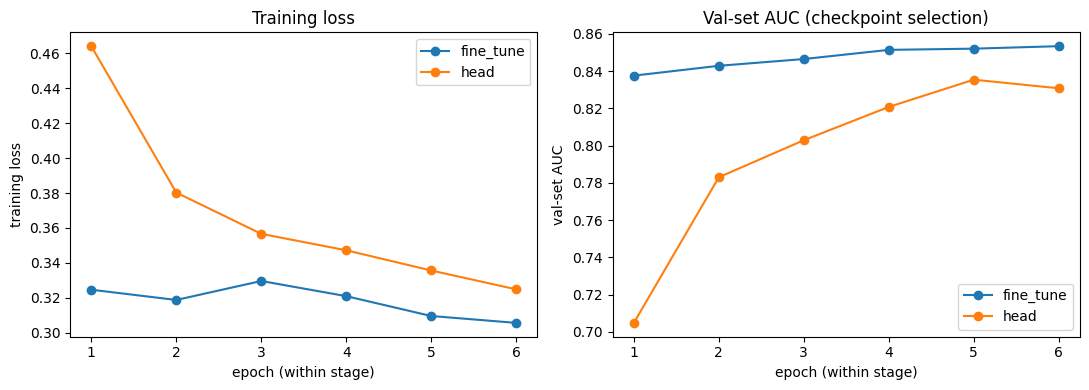

In [33]:
# Plot the training curves (loss and val-set AUC per epoch, per stage).
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for stage, group in history_df.groupby("stage"):
    axes[0].plot(group["epoch"], group["loss"], marker="o", label=stage)
    axes[1].plot(group["epoch"], group["val_auc"], marker="o", label=stage)
axes[0].set_xlabel("epoch (within stage)"); axes[0].set_ylabel("training loss"); axes[0].set_title("Training loss")
axes[1].set_xlabel("epoch (within stage)"); axes[1].set_ylabel("val-set AUC"); axes[1].set_title("Val-set AUC (checkpoint selection)")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=160)
plt.show()

## Calibration, Bayesian Thresholds, and Uncertainty

**Theory — calibration.** A classifier is calibrated if, among all cases where it outputs $P(\text{mel})=p$,
roughly a fraction $p$ are truly melanoma. Raw network logits are frequently over-confident; **Platt scaling**
fits a 1-D logistic transform $a\cdot\text{logit} + b$ on a held-out calibration split (`cal_df`, never seen
during training) to correct this. We quantify calibration with the **Expected Calibration Error (ECE)** —
the (bin-weighted) average gap between predicted confidence and empirical accuracy — and the **Brier score**
(mean squared error of the probability against the 0/1 outcome), and visualize it with a **reliability
diagram**: predicted-probability bins on the x-axis, empirical positive-rate on the y-axis, with the diagonal
as the "perfectly calibrated" reference.

**Theory — MC Dropout.** Keeping dropout active at inference time and running $T$ stochastic forward passes
approximates sampling from an approximate posterior over network weights (Gal & Ghahramani, 2016). Averaging
the $T$ probability samples gives the predictive mean; the spread across samples estimates uncertainty. We
decompose total predictive entropy into:
- **Aleatoric uncertainty** (expected entropy of each pass) — irreducible ambiguity in the image itself.
- **Epistemic uncertainty** (mutual information between the prediction and the model's own weight
  posterior, a.k.a. BALD) — uncertainty that more data or a better model *could* reduce.

High epistemic uncertainty is the signal you'd want to route to manual/expert review rather than trusting
either an automatic "clear" or automatic "urgent" call.

### Calibration and MC-Dropout helper functions

In [34]:
def collect_logits(model, loader):
    model.eval()
    logits_all = []
    targets_all = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits = model(images).squeeze(1)
            logits_all.append(logits.float().cpu())
            targets_all.append(labels.float())
    return torch.cat(logits_all), torch.cat(targets_all)

class PlattScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.ones(1))
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        return self.a * logits + self.b

def fit_platt_scaler(logits, labels):
    scaler_model = PlattScaler()
    criterion_platt = nn.BCEWithLogitsLoss()
    optimizer_platt = torch.optim.LBFGS(scaler_model.parameters(), lr=0.05, max_iter=100)

    def closure():
        optimizer_platt.zero_grad()
        loss = criterion_platt(scaler_model(logits), labels)
        loss.backward()
        return loss

    optimizer_platt.step(closure)
    return float(scaler_model.a.detach().item()), float(scaler_model.b.detach().item())

def apply_platt(logits, a, b):
    return a * logits + b

def enable_dropout(module):
    for child in module.modules():
        if child.__class__.__name__.startswith("Dropout"):
            child.train()

def mc_dropout_predict(model, loader, passes=MC_PASSES, platt_a=1.0, platt_b=0.0):
    model.eval()
    enable_dropout(model)
    all_passes = []
    targets = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            targets.extend(labels.numpy())
            batch_passes = []
            for _ in range(passes):
                with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                    logits = model(images).squeeze(1)
                calibrated_logits = apply_platt(logits.float(), platt_a, platt_b)
                probs = torch.sigmoid(calibrated_logits).cpu().numpy()
                batch_passes.append(probs)
            all_passes.append(np.stack(batch_passes, axis=0))

    return np.concatenate(all_passes, axis=1), np.asarray(targets)

def uncertainty_from_mc(all_probs):
    predictive_mean = all_probs.mean(axis=0)
    predictive_entropy = -(
        predictive_mean * np.log(predictive_mean + 1e-10)
        + (1 - predictive_mean) * np.log(1 - predictive_mean + 1e-10)
    )
    expected_entropy = np.mean(
        -(all_probs * np.log(all_probs + 1e-10) + (1 - all_probs) * np.log(1 - all_probs + 1e-10)),
        axis=0,
    )
    mutual_information = predictive_entropy - expected_entropy
    return predictive_mean, predictive_entropy, mutual_information

### Fit Platt scaling and run MC-Dropout inference

Platt scaling is fit on the calibration split only; MC-Dropout inference then yields calibrated predictive means and epistemic-uncertainty estimates on the cal and test splits.

In [35]:
# Platt scaling is fit ONLY on the calibration split.
cal_logits, cal_targets_tensor = collect_logits(model, cal_loader)
platt_a, platt_b = fit_platt_scaler(cal_logits, cal_targets_tensor)
print(f"Platt scaling parameters: a={platt_a:.3f}, b={platt_b:.3f}")

cal_all_probs, cal_targets = mc_dropout_predict(model, cal_loader, passes=MC_PASSES, platt_a=platt_a, platt_b=platt_b)
cal_predictive_mean, cal_predictive_entropy, cal_mutual_information = uncertainty_from_mc(cal_all_probs)

# Final reported deep-model metrics come from the held-out test split.
test_all_probs, test_targets = mc_dropout_predict(model, test_loader, passes=MC_PASSES, platt_a=platt_a, platt_b=platt_b)
test_predictive_mean, test_predictive_entropy, test_mutual_information = uncertainty_from_mc(test_all_probs)

# Raw (uncalibrated, single-pass) test probabilities, kept so the reliability diagram can show
# the effect of Platt scaling as a before/after comparison.
raw_test_probs, _ = predict_probs(model, test_loader)

test_auc = roc_auc_score(test_targets, test_predictive_mean)
brier = brier_score_loss(test_targets, test_predictive_mean)
print(f"EfficientNet MC Platt-calibrated TEST AUC: {test_auc:.4f}")
print(f"Brier score (test): {brier:.4f}")

Platt scaling parameters: a=1.184, b=-0.557
EfficientNet MC Platt-calibrated TEST AUC: 0.8199
Brier score (test): 0.0804


### Deep decision rule (MAP vs. asymmetric cost) + operating points + triage zones

### Decision-rule helper functions

In [36]:
def expected_calibration_error(y_true, y_prob, bins=10):
    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (y_prob > lo) & (y_prob <= hi)
        if not np.any(mask):
            continue
        empirical_rate = y_true[mask].mean()
        confidence = y_prob[mask].mean()
        ece += mask.mean() * abs(empirical_rate - confidence)
    return ece

def find_threshold_for_min_sensitivity(probs, y_true, min_sensitivity=0.98):
    rows = []
    for tau in np.linspace(0.0, 1.0, 1001):
        m = metrics_at_threshold(probs, y_true, tau)
        if m["sensitivity"] >= min_sensitivity:
            rows.append((tau, m))
    if not rows:
        return None
    return max(rows, key=lambda row: row[1]["specificity"])

def selected_threshold_row(cal_probs, cal_y, test_probs, test_y, min_sensitivity, model_name):
    selected = find_threshold_for_min_sensitivity(cal_probs, cal_y, min_sensitivity)
    if selected is None:
        return {"model": model_name, "target_sensitivity": min_sensitivity, "selected_threshold": np.nan}
    tau, cal_m = selected
    test_m = metrics_at_threshold(test_probs, test_y, tau)
    return {
        "model": model_name, "target_sensitivity": min_sensitivity, "selected_threshold": tau,
        "cal_sensitivity": cal_m["sensitivity"], "cal_specificity": cal_m["specificity"],
        "cal_referral_rate": cal_m["referral_rate"],
        "test_sensitivity": test_m["sensitivity"], "test_specificity": test_m["specificity"],
        "test_precision": test_m["precision"], "test_referral_rate": test_m["referral_rate"],
        "test_false_negatives": test_m["false_negatives"], "test_false_positives": test_m["false_positives"],
    }

def triage_zone_summary(probs, mi, y_true, low_threshold, high_threshold=0.5, uncertainty_threshold=None):
    if uncertainty_threshold is None:
        uncertainty_threshold = np.quantile(mi, 0.95)
    low_risk = (probs < low_threshold) & (mi < uncertainty_threshold)
    high_risk = probs >= high_threshold
    manual_review = ~(low_risk | high_risk)
    positives = y_true == 1
    auto_clear_fn = int((low_risk & positives).sum())
    urgent_tp = int((high_risk & positives).sum())
    urgent_fp = int((high_risk & ~positives).sum())
    return {
        "low_threshold": low_threshold, "high_threshold": high_threshold,
        "uncertainty_threshold": uncertainty_threshold,
        "auto_reassured_rate": low_risk.mean(), "manual_review_rate": manual_review.mean(),
        "urgent_referral_rate": high_risk.mean(),
        "false_negatives_auto_reassured": auto_clear_fn,
        "sensitivity_after_auto_reassurance": 1 - (auto_clear_fn / positives.sum() if positives.sum() else 0.0),
        "urgent_referral_precision": urgent_tp / (urgent_tp + urgent_fp) if (urgent_tp + urgent_fp) else 0.0,
    }

### Compute decision metrics, operating points, and triage zones

Cost-sweep table (both models), sensitivity-targeted operating points, calibration errors, and uncertainty-aware triage zones — written to CSV and printed.

In [37]:
# --- deep-model cost sweep, appended to the classical rows from earlier for one unified table ---
deep_cost_rows = [
    evaluate_threshold(test_predictive_mean, test_targets, l_fn, l_fp, "deep_efficientnet")
    for l_fn, l_fp in COST_SWEEP
]
cost_comparison_df = pd.concat([classical_cost_df, pd.DataFrame(deep_cost_rows)], ignore_index=True)

operating_point_df = pd.concat([
    pd.DataFrame([selected_threshold_row(gmm_probs_val, y_val_gmm, gmm_probs_test, y_test_gmm, s, "classical_gmm")
                  for s in [0.95, 0.98, 0.99]]),
    pd.DataFrame([selected_threshold_row(cal_predictive_mean, cal_targets, test_predictive_mean, test_targets, s, "deep_efficientnet")
                  for s in [0.95, 0.98, 0.99]]),
], ignore_index=True)

ece_test_calibrated = expected_calibration_error(test_targets, test_predictive_mean)
ece_test_raw = expected_calibration_error(test_targets, raw_test_probs)
ece_cal = expected_calibration_error(cal_targets, cal_predictive_mean)
ece_classical = expected_calibration_error(y_test_gmm, gmm_probs_test)

# Uncertainty-aware triage zones (deep model only -- MC Dropout's epistemic-uncertainty
# estimate has no direct classical-GMM analogue in this pipeline; see markdown discussion).
low_threshold_row = operating_point_df.query("model == 'deep_efficientnet' and target_sensitivity == 0.99")
low_threshold = float(low_threshold_row["selected_threshold"].iloc[0]) if len(low_threshold_row) and np.isfinite(low_threshold_row["selected_threshold"].iloc[0]) else tau_cost
uncertainty_threshold = float(np.quantile(cal_mutual_information, 0.95))
triage_zone_df = pd.DataFrame([
    triage_zone_summary(test_predictive_mean, test_mutual_information, test_targets,
                         low_threshold, high_threshold=0.5, uncertainty_threshold=uncertainty_threshold)
])

summary_df = pd.DataFrame([
    {"metric": "classical_gmm_test_auc", "value": auc(gmm_fpr, gmm_tpr)},
    {"metric": "deep_efficientnet_test_auc", "value": test_auc},
    {"metric": "deep_brier_score_test", "value": brier},
    {"metric": "deep_ece_test_calibrated", "value": ece_test_calibrated},
    {"metric": "deep_ece_test_raw", "value": ece_test_raw},
    {"metric": "deep_ece_cal_split", "value": ece_cal},
    {"metric": "classical_ece_test", "value": ece_classical},
    {"metric": "platt_a", "value": platt_a},
    {"metric": "platt_b", "value": platt_b},
    {"metric": "mc_passes", "value": MC_PASSES},
    {"metric": "fine_tune_backbone", "value": FINE_TUNE_BACKBONE},
    {"metric": "primary_cost_fn_fp", "value": f"{FN_COST}:{FP_COST}"},
    {"metric": "primary_cost_threshold", "value": tau_cost},
])

predictions_df = test_df[["image_id", "lesion_id", "dx", "target"]].copy()
predictions_df["prob_classical_gmm"] = gmm_probs_test
predictions_df["prob_deep_efficientnet"] = test_predictive_mean
predictions_df["predictive_entropy"] = test_predictive_entropy
predictions_df["mutual_information"] = test_mutual_information
low_risk_mask = (test_predictive_mean < low_threshold) & (test_mutual_information < uncertainty_threshold)
high_risk_mask = test_predictive_mean >= 0.5
predictions_df["triage_zone"] = np.select(
    [low_risk_mask, high_risk_mask],
    ["low_risk_auto_reassure", "high_risk_urgent_referral"],
    default="manual_review",
)

cost_comparison_df.to_csv(OUTPUT_DIR / "cost_sweep_comparison.csv", index=False)
operating_point_df.to_csv(OUTPUT_DIR / "sensitivity_operating_points.csv", index=False)
triage_zone_df.to_csv(OUTPUT_DIR / "triage_zone_metrics.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "summary_metrics.csv", index=False)
predictions_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

print(f"Deep TEST ECE: calibrated={ece_test_calibrated:.4f} vs raw={ece_test_raw:.4f} "
      f"(lower is better; compare to see whether Platt scaling helped)")
print(f"Classical TEST ECE: {ece_classical:.4f}")
print("\nUnified cost-sensitive decision comparison (classical vs. deep, same test lesions):")
print(cost_comparison_df.to_string(index=False, formatters={
    "threshold": "{:.3f}".format, "sensitivity": "{:.3f}".format,
    "specificity": "{:.3f}".format, "precision": "{:.3f}".format, "referral_rate": "{:.3f}".format,
}))
print("\nSensitivity-targeted operating points (threshold picked on cal/val, evaluated on test):")
print(operating_point_df.to_string(index=False))
print("\nUncertainty-aware triage zones (deep model, test set):")
print(triage_zone_df.to_string(index=False))
print(f"\nSaved metrics and predictions to {OUTPUT_DIR.resolve()}")

Deep TEST ECE: calibrated=0.0178 vs raw=0.0673 (lower is better; compare to see whether Platt scaling helped)
Classical TEST ECE: 0.1430

Unified cost-sensitive decision comparison (classical vs. deep, same test lesions):
            model cost_ratio_fn_fp threshold sensitivity specificity precision referral_rate  false_negatives  false_positives  true_negatives  true_positives
    classical_gmm              1:1     0.500       0.355       0.908     0.317         0.120              129              153            1507              71
    classical_gmm              5:1     0.167       0.370       0.898     0.305         0.131              126              169            1491              74
    classical_gmm             10:1     0.091       0.385       0.892     0.301         0.138              123              179            1481              77
    classical_gmm             20:1     0.048       0.420       0.886     0.308         0.147              116              189            1471

## Expected Output: ROC Curves

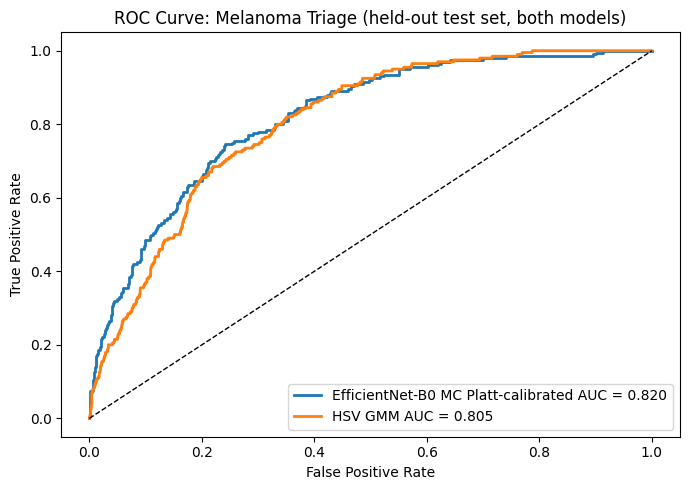

In [38]:
fpr, tpr, _ = roc_curve(test_targets, test_predictive_mean)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f"EfficientNet-B0 MC Platt-calibrated AUC = {auc(fpr, tpr):.3f}")
plt.plot(gmm_fpr, gmm_tpr, lw=2, label=f"HSV GMM AUC = {auc(gmm_fpr, gmm_tpr):.3f}")
plt.plot([0, 1], [0, 1], color="black", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Melanoma Triage (held-out test set, both models)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_triage.png", dpi=160)
plt.show()

## Reliability / Calibration Analysis

The reliability diagram plots predicted-probability bins against the empirical melanoma rate, with
the diagonal as the perfectly-calibrated reference. Three curves are shown — the classical GMM, the
deep model's raw logits, and the deep model after Platt scaling — so the effect of calibration is
visible directly.

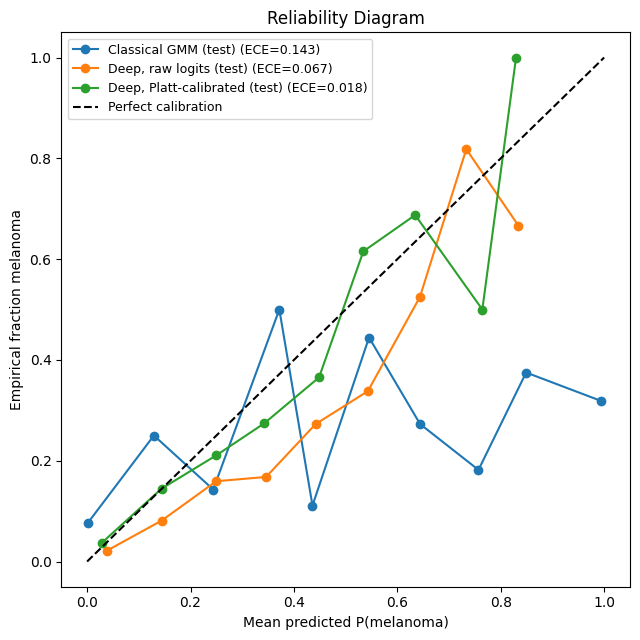

In [39]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
curves = [
    ("Classical GMM (test)", y_test_gmm, gmm_probs_test, ece_classical),
    ("Deep, raw logits (test)", test_targets, raw_test_probs, ece_test_raw),
    ("Deep, Platt-calibrated (test)", test_targets, test_predictive_mean, ece_test_calibrated),
]
for label, y_true, y_prob, ece_value in curves:
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{label} (ECE={ece_value:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted P(melanoma)")
ax.set_ylabel("Empirical fraction melanoma")
ax.set_title("Reliability Diagram")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reliability_diagram.png", dpi=160)
plt.show()

## Confusion Matrices

Each model is shown at both its MAP threshold (0.5) and its primary asymmetric-cost threshold, so
the shift in false negatives/positives from changing the decision rule is visible directly.

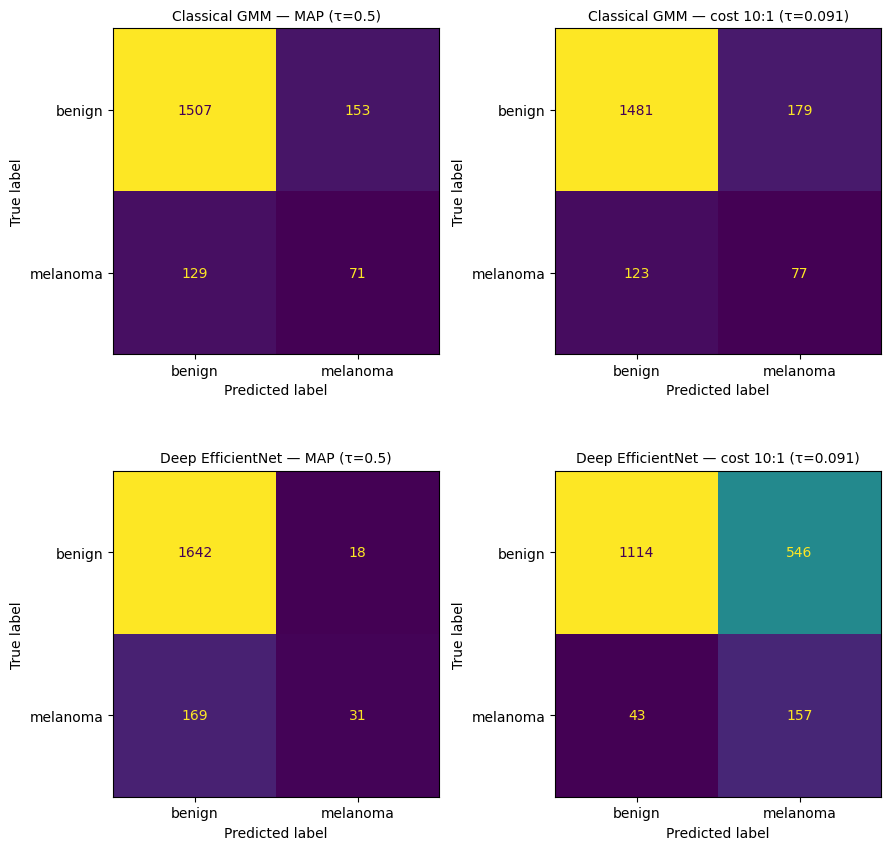

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
combos = [
    ("Classical GMM — MAP (τ=0.5)", y_test_gmm, gmm_probs_test, tau_map),
    (f"Classical GMM — cost {FN_COST}:{FP_COST} (τ={tau_cost:.3f})", y_test_gmm, gmm_probs_test, tau_cost),
    ("Deep EfficientNet — MAP (τ=0.5)", test_targets, test_predictive_mean, tau_map),
    (f"Deep EfficientNet — cost {FN_COST}:{FP_COST} (τ={tau_cost:.3f})", test_targets, test_predictive_mean, tau_cost),
]
for ax, (title, y_true, y_prob, tau) in zip(axes.ravel(), combos):
    preds = (y_prob >= tau).astype(int)
    cm = confusion_matrix(y_true, preds, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["benign", "melanoma"]).plot(ax=ax, colorbar=False)
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=160)
plt.show()

## Expected Output: Uncertainty Examples

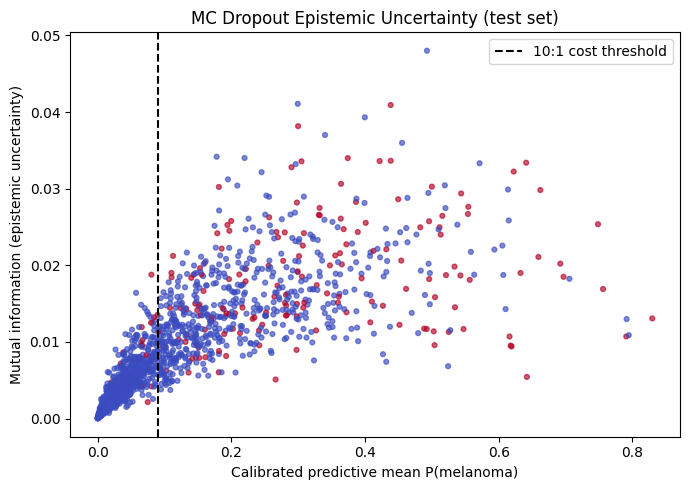

In [41]:
# The threshold line uses the computed tau_cost, so it always matches FN_COST/FP_COST.
plt.figure(figsize=(7, 5))
plt.scatter(test_predictive_mean, test_mutual_information, c=test_targets, cmap="coolwarm", s=12, alpha=0.65)
plt.axvline(tau_cost, color="black", linestyle="--", label=f"{FN_COST}:{FP_COST} cost threshold")
plt.xlabel("Calibrated predictive mean P(melanoma)")
plt.ylabel("Mutual information (epistemic uncertainty)")
plt.title("MC Dropout Epistemic Uncertainty (test set)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "uncertainty_scatter.png", dpi=160)
plt.show()

## Comparison of Classical and Deep Triage Decisions

Both models' decisions are computed on the *same* held-out test lesions at the same asymmetric-cost
threshold, which lets us measure their agreement and identify the lesions they disagree on.

Agreement rate at the 10:1 cost threshold: 0.688
Melanomas missed by BOTH models: 26
Referred by classical only: 67; referred by deep only: 514


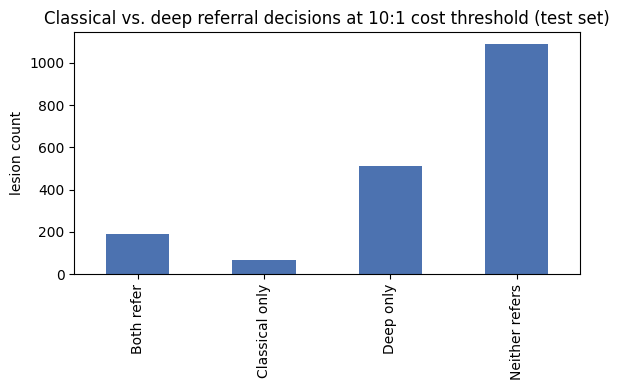

In [42]:
comparison_df = test_df[["image_id", "lesion_id", "dx", "target"]].copy()
comparison_df["prob_classical"] = gmm_probs_test
comparison_df["prob_deep"] = test_predictive_mean
comparison_df["mutual_information"] = test_mutual_information
comparison_df["decision_classical"] = (gmm_probs_test >= tau_cost).astype(int)
comparison_df["decision_deep"] = (test_predictive_mean >= tau_cost).astype(int)
comparison_df["agree"] = comparison_df["decision_classical"] == comparison_df["decision_deep"]
comparison_df.to_csv(OUTPUT_DIR / "classical_vs_deep_predictions.csv", index=False)

agree_rate = comparison_df["agree"].mean()
both_miss = ((comparison_df["target"] == 1) & (comparison_df["decision_classical"] == 0) & (comparison_df["decision_deep"] == 0)).sum()
classical_only_referral = ((comparison_df["decision_classical"] == 1) & (comparison_df["decision_deep"] == 0)).sum()
deep_only_referral = ((comparison_df["decision_deep"] == 1) & (comparison_df["decision_classical"] == 0)).sum()

print(f"Agreement rate at the {FN_COST}:{FP_COST} cost threshold: {agree_rate:.3f}")
print(f"Melanomas missed by BOTH models: {both_miss}")
print(f"Referred by classical only: {classical_only_referral}; referred by deep only: {deep_only_referral}")

fig, ax = plt.subplots(figsize=(6, 4))
counts = pd.Series({
    "Both refer": ((comparison_df.decision_classical == 1) & (comparison_df.decision_deep == 1)).sum(),
    "Classical only": classical_only_referral,
    "Deep only": deep_only_referral,
    "Neither refers": ((comparison_df.decision_classical == 0) & (comparison_df.decision_deep == 0)).sum(),
})
counts.plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_ylabel("lesion count")
ax.set_title(f"Classical vs. deep referral decisions at {FN_COST}:{FP_COST} cost threshold (test set)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "classical_vs_deep_decisions.png", dpi=160)
plt.show()

### Example Gallery (successes and failures)

A gallery spanning both successes and failures: a clean low-risk benign, a clean urgent melanoma, a
near-threshold case, the most epistemically uncertain case, an explicit false negative, an explicit
false positive, and a case where the classical and deep models disagree.

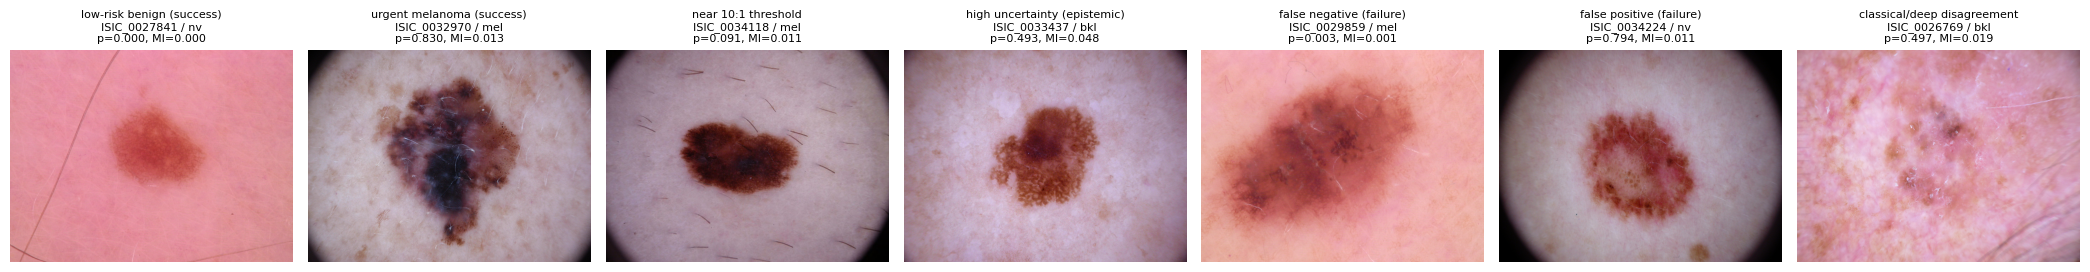

In [43]:
def first_or_none(frame):
    return frame.iloc[0] if len(frame) else None

example_specs = [
    ("low-risk benign (success)", predictions_df.sort_values("prob_deep_efficientnet").query("target == 0").head(1)),
    ("urgent melanoma (success)", predictions_df.sort_values("prob_deep_efficientnet", ascending=False).query("target == 1").head(1)),
    (f"near {FN_COST}:{FP_COST} threshold", predictions_df.iloc[(predictions_df["prob_deep_efficientnet"] - tau_cost).abs().argsort()].head(1)),
    ("high uncertainty (epistemic)", predictions_df.sort_values("mutual_information", ascending=False).head(1)),
    ("false negative (failure)", predictions_df.query("target == 1 and prob_deep_efficientnet < @tau_cost")
        .sort_values("prob_deep_efficientnet").head(1)),
    ("false positive (failure)", predictions_df.query("target == 0 and prob_deep_efficientnet >= @tau_cost")
        .sort_values("prob_deep_efficientnet", ascending=False).head(1)),
    ("classical/deep disagreement", comparison_df.query("not agree").head(1)),
]
example_specs = [(role, frame) for role, frame in example_specs if len(frame)]

fig, axes = plt.subplots(1, len(example_specs), figsize=(3.0 * len(example_specs), 3.4))
if len(example_specs) == 1:
    axes = [axes]
path_lookup = test_df.set_index("image_id")["image_path"].to_dict()

for ax, (role, frame) in zip(axes, example_specs):
    row = frame.iloc[0]
    image = Image.open(path_lookup[row["image_id"]]).convert("RGB")
    ax.imshow(image)
    ax.axis("off")
    prob_col = "prob_deep_efficientnet" if "prob_deep_efficientnet" in row else "prob_deep"
    mi_val = row["mutual_information"] if "mutual_information" in row else float("nan")
    ax.set_title(f"{role}\n{row['image_id']} / {row['dx']}\np={row[prob_col]:.3f}, MI={mi_val:.3f}", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "example_lesions_grid.png", dpi=180)
plt.show()

## Diagnostics: BIC Curves for GMM Component Selection

The BIC curve for each class, with the selected component count marked. A minimum near the edge of
the search range is a sign that the range should be widened or that the fit is unstable — worth
watching for the smaller melanoma class. A fresh figure is created per class and saved before
display.

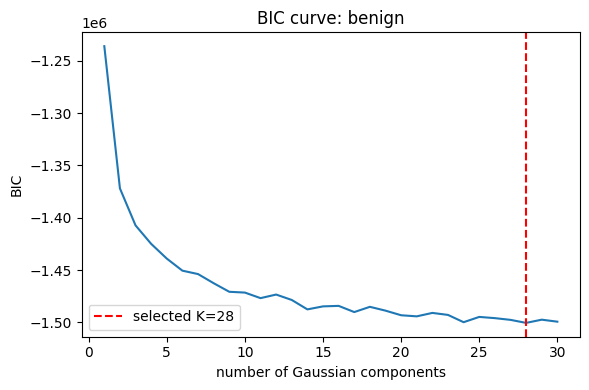

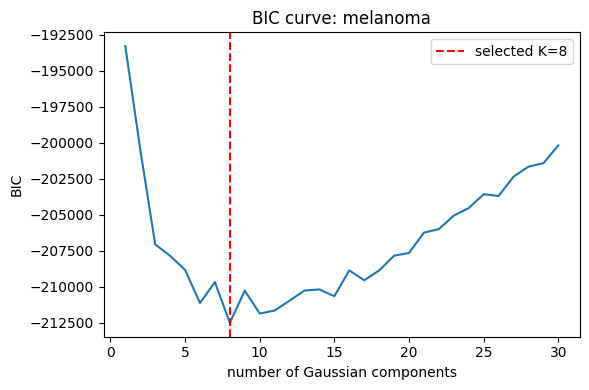

In [44]:
# x-axis length matches each class's own (possibly sample-size-capped) search range.
fig1 = plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, class_max_k[0] + 1), np.array(bic_scores[0]))
plt.axvline(k_benign, color="red", linestyle="--", label=f"selected K={k_benign}")
plt.xlabel("number of Gaussian components")
plt.ylabel("BIC")
plt.title("BIC curve: benign")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bic_curve_benign.png", dpi=160)
plt.show()

fig2 = plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, class_max_k[1] + 1), np.array(bic_scores[1]))
plt.axvline(k_mel, color="red", linestyle="--", label=f"selected K={k_mel}")
plt.xlabel("number of Gaussian components")
plt.ylabel("BIC")
plt.title("BIC curve: melanoma")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bic_curve_melanoma.png", dpi=160)
plt.show()

## Reproducibility Metadata

Saves the seed, feature configuration, selected GMM component counts, cost matrix, package
versions, split sizes, and wall-clock runtime the run used to `run_config.json`.

In [45]:
total_runtime_seconds = time.time() - NOTEBOOK_START_TIME
run_config = {
    "seed": SEED,
    "hsv_bins": HSV_BINS,
    "gmm_max_components_searched": GMM_MAX_COMPONENTS,
    "gmm_selected_k": {"benign": k_benign, "melanoma": k_mel},
    "gmm_fit_subsample_size": int(_gmm_fit_n),
    "primary_cost_matrix": {"fn_cost": FN_COST, "fp_cost": FP_COST, "tau": tau_cost},
    "cost_sweep_ratios": COST_SWEEP,
    "fine_tune_backbone": FINE_TUNE_BACKBONE,
    "head_epochs": HEAD_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS if FINE_TUNE_BACKBONE else 0,
    "unfreeze_last_blocks": UNFREEZE_LAST_BLOCKS if FINE_TUNE_BACKBONE else 0,
    "mc_dropout_passes": MC_PASSES,
    "batch_size": BATCH_SIZE,
    "runtime_minutes": {
        "head_training": round(head_train_seconds / 60, 2),
        "fine_tuning": round(fine_tune_seconds / 60, 2),
        "total_notebook_so_far": round(total_runtime_seconds / 60, 2),
    },
    "split_sizes": {
        "fit": len(fit_df), "val": len(val_df), "cal": len(cal_df), "test": len(test_df),
    },
    "package_versions": {
        "python": platform.python_version(), "torch": torch.__version__,
        "sklearn": sklearn.__version__, "opencv": cv2.__version__,
        "pandas": pd.__version__, "numpy": np.__version__,
    },
}
with open(OUTPUT_DIR / "run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)
print(json.dumps(run_config, indent=2))

{
  "seed": 42,
  "hsv_bins": 32,
  "gmm_max_components_searched": 30,
  "gmm_selected_k": {
    "benign": 28,
    "melanoma": 8
  },
  "gmm_fit_subsample_size": 2000,
  "primary_cost_matrix": {
    "fn_cost": 10,
    "fp_cost": 1,
    "tau": 0.09090909090909091
  },
  "cost_sweep_ratios": [
    [
      1,
      1
    ],
    [
      5,
      1
    ],
    [
      10,
      1
    ],
    [
      20,
      1
    ]
  ],
  "fine_tune_backbone": true,
  "head_epochs": 6,
  "fine_tune_epochs": 6,
  "unfreeze_last_blocks": 2,
  "mc_dropout_passes": 30,
  "batch_size": 128,
  "runtime_minutes": {
    "head_training": 3.27,
    "fine_tuning": 3.27,
    "total_notebook_so_far": 9.38
  },
  "split_sizes": {
    "fit": 4750,
    "val": 1146,
    "cal": 1418,
    "test": 1860
  },
  "package_versions": {
    "python": "3.12.12",
    "torch": "2.10.0+cu128",
    "sklearn": "1.6.1",
    "opencv": "4.13.0",
    "pandas": "2.3.3",
    "numpy": "2.0.2"
  }
}


## Outputs

The notebook writes all downloadable artifacts to `/kaggle/working/outputs/`:

- `split_assignment.csv` — exact fit/val/cal/test membership per image (reproducibility)
- `training_history.csv`, `training_curves.png`
- `class_balance.png`
- `raw_vs_processed_feature.png`
- `bayes_decision_boundary.png`
- `bic_curve_benign.png`, `bic_curve_melanoma.png`
- `roc_curve_triage.png`
- `reliability_diagram.png`
- `confusion_matrices.png`
- `uncertainty_scatter.png`
- `classical_vs_deep_decisions.png`, `classical_vs_deep_predictions.csv`
- `example_lesions_grid.png`
- `cost_sweep_comparison.csv` — classical + deep at MAP and asymmetric-cost thresholds
- `sensitivity_operating_points.csv`
- `triage_zone_metrics.csv`
- `summary_metrics.csv`
- `test_predictions.csv`
- `run_config.json` — seed, split sizes, GMM K, cost matrix, package versions

Download the `outputs/` folder from Kaggle and copy it into `experiments/outputs/` to refresh the
committed results.

In [46]:
from IPython.display import FileLink, FileLinks, display
import shutil

output_dir = OUTPUT_DIR.resolve()
archive_path = shutil.make_archive(str(output_dir), "zip", root_dir=output_dir)

print(f"Output directory: {output_dir}")
print(f"Created archive: {archive_path}")

Output directory: /kaggle/working/outputs
Created archive: /kaggle/working/outputs.zip
